# Loading, reading and executing the inception v3 tensorflow 1 graph
A useful medium article: [TensorFlow: How to freeze a model and serve it with a python API](https://blog.metaflow.fr/tensorflow-how-to-freeze-a-model-and-serve-it-with-a-python-api-d4f3596b3adc)

In [1]:
!pip freeze list | grep tensorflow

tensorflow==1.15.0
tensorflow-estimator==1.15.1


In [1]:
import os

os.chdir("/home/prateek/Documents/projects/headpose-estimation/")
print(os.getcwd())

/home/prateek/Documents/projects/headpose-estimation


## Setup a tensorflow session

In [2]:
import tensorflow as tf

session = tf.Session()

2026-05-17 14:39:22.334369: W tensorflow/stream_executor/platform/default/dso_loader.cc:55] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-05-17 14:39:22.334394: E tensorflow/stream_executor/cuda/cuda_driver.cc:318] failed call to cuInit: UNKNOWN ERROR (303)
2026-05-17 14:39:22.334414: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (bleu): /proc/driver/nvidia/version does not exist
2026-05-17 14:39:22.334898: I tensorflow/core/platform/cpu_feature_guard.cc:142] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 FMA
2026-05-17 14:39:22.341257: I tensorflow/core/platform/profile_utils/cpu_utils.cc:94] CPU Frequency: 1796820000 Hz
2026-05-17 14:39:22.342414: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x59149ea30b20 initialized for platform Host (this does not guarantee that XLA wi

## Load the tensorflow model and add it to the current session

In [ ]:
# download the model file and extract it
!wget -P models/inception_v3/ -O models/inception_v3/inception-2015-12-05.tgz http://download.tensorflow.org/models/image/imagenet/inception-2015-12-05.tgz && tar -xzvf models/inception_v3/inception-2015-12-05.tgz -C models/inception_v3/

models/inception_v3/: No such file or directory


In [3]:
graphdef_file = "models/inception_v3/classify_image_graph_def.pb"

with tf.gfile.GFile(graphdef_file, "rb") as f:
  graph_def = tf.GraphDef()
  graph_def.ParseFromString(f.read())

In [5]:
tf.import_graph_def(graph_def)

2026-05-16 18:28:09.434723: W tensorflow/core/framework/op_def_util.cc:357] Op BatchNormWithGlobalNormalization is deprecated. It will cease to work in GraphDef version 9. Use tf.nn.batch_normalization().


In [6]:
# print all the operations in the model
for op in tf.get_default_graph().get_operations():
  print(op.name)


import/DecodeJpeg/contents
import/DecodeJpeg
import/Cast
import/ExpandDims/dim
import/ExpandDims
import/ResizeBilinear/size
import/ResizeBilinear
import/Sub/y
import/Sub
import/Mul/y
import/Mul
import/conv/conv2d_params
import/conv/Conv2D
import/conv/batchnorm/beta
import/conv/batchnorm/gamma
import/conv/batchnorm/moving_mean
import/conv/batchnorm/moving_variance
import/conv/batchnorm
import/conv/CheckNumerics
import/conv/control_dependency
import/conv
import/conv_1/conv2d_params
import/conv_1/Conv2D
import/conv_1/batchnorm/beta
import/conv_1/batchnorm/gamma
import/conv_1/batchnorm/moving_mean
import/conv_1/batchnorm/moving_variance
import/conv_1/batchnorm
import/conv_1/CheckNumerics
import/conv_1/control_dependency
import/conv_1
import/conv_2/conv2d_params
import/conv_2/Conv2D
import/conv_2/batchnorm/beta
import/conv_2/batchnorm/gamma
import/conv_2/batchnorm/moving_mean
import/conv_2/batchnorm/moving_variance
import/conv_2/batchnorm
import/conv_2/CheckNumerics
import/conv_2/control_d

Looking at the operations we need two operations to start with
1. import/DecodeJpeg/contents
2. import/pool_3/_reshape

The first one is the input to the tf graph and the second one will give us the model's representation of the input image.

Additionally we can also get the following operations to check their values and ensure we are running the graph correctly

3. import/DecodeJpeg
4. import/softmax

There are two way to get these tensors:

1. we can get them when we load the graph (it seems that when getting the tensor during loading the graph we need to skip the `import/` fromt the names and also we need to append the `:0` to their names)

```
input_tensor, decoded_image_tensor, output_tensor, softmax_logits_tensor = tf.import_graph_def(
    graph_def,
    return_elements = [
        "DecodeJpeg/contents:0",
        "DecodeJpeg:0",
        "pool_3/_reshape:0",
        "softmax:0"
    ]
)
```

2. Since we have already loaded our graph we can use the `graph.get_tensor_by_name('<name of the tensor>')`

In [ ]:
for node in graph_def.node:
  if node.name == "DecodeJpeg":
    node.op

<class 'str'>


In [6]:
graph = tf.get_default_graph()
input_tensor = graph.get_tensor_by_name("import/DecodeJpeg/contents:0")
casting_tensor = graph.get_tensor_by_name("import/Cast:0")
softmax_logit_tensor = graph.get_tensor_by_name("import/softmax:0")
resize_tensor = graph.get_tensor_by_name("import/ResizeBilinear:0")
sub_tensor = graph.get_tensor_by_name("import/Sub:0")
mul_tensor = graph.get_tensor_by_name("import/Mul:0")
first_conv_tensor = graph.get_tensor_by_name("import/conv_1/Conv2D:0")
model_image_representation_tensor = graph.get_tensor_by_name("import/pool_3/_reshape:0")
tf_decoded_image_tensor = graph.get_tensor_by_name("import/DecodeJpeg:0")

## Load an image for testing

In [7]:
IMAGE_PATH = "scripts/notebooks/data/AFW_134212_1_0.jpg"

image_data = tf.gfile.FastGFile(IMAGE_PATH, "rb").read()

Instructions for updating:
Use tf.gfile.GFile.


In [8]:
type(image_data)

bytes

## Run the image through the model

In [9]:
resize_tensor_output, casting_tensor_output, mul_tensor_output, model_representation, softmax_logits = session.run(
  [
    resize_tensor,
    casting_tensor,
    mul_tensor,
    model_image_representation_tensor,
    softmax_logit_tensor,
  ],
  feed_dict={input_tensor: image_data},
)

In [10]:
print(type(mul_tensor_output))
print(type(model_representation))
print(type(softmax_logits))
print(mul_tensor_output.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(1, 299, 299, 3)


In [11]:
print(casting_tensor_output.shape)

(450, 450, 3)


In [45]:
print("Resized tensor!!")
print(resize_tensor_output[0, 0, :30, 0])

normalized_tensor_output = (resize_tensor_output - 128.0) * 0.0078125
print("Normalized tensor!!")
print(normalized_tensor_output[0, 0, :30, 0])

print("Mul tensor!!")
print(mul_tensor_output[0, 0, :30, 0])

Resized tensor!!
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Normalized tensor!!
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
Mul tensor!!
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]


Try to run a batched call through the model itself without the resizing nodes.

In [15]:
import numpy as np

intermediate_feed_representation_output, intermediate_feed_softmax_logit = session.run(
  [
    model_image_representation_tensor,
    softmax_logit_tensor,
  ],
  feed_dict={mul_tensor: mul_tensor_output},
)

In [17]:
np.allclose(intermediate_feed_representation_output, model_representation, rtol=1e-6, atol=1e-6)

True

In [18]:
intermediate_feed_representation_output[0, :30]

array([0.33434555, 0.07754004, 0.35431096, 0.30379552, 0.7538025 ,
       0.2194451 , 0.31085014, 0.19215798, 0.23283122, 0.31013975,
       0.30067554, 0.7713815 , 0.07217857, 0.32011855, 0.43579608,
       0.10116448, 0.44117236, 0.42960697, 0.14566684, 0.06445607,
       0.27869734, 0.26063445, 0.70221865, 0.67185044, 0.19727473,
       0.19590643, 0.52652806, 0.04644649, 0.17923523, 1.3919828 ],
      dtype=float32)

In [19]:
model_representation[0, :30]

array([0.33434555, 0.07754004, 0.35431096, 0.30379552, 0.7538025 ,
       0.2194451 , 0.31085014, 0.19215798, 0.23283122, 0.31013975,
       0.30067554, 0.7713815 , 0.07217857, 0.32011855, 0.43579608,
       0.10116448, 0.44117236, 0.42960697, 0.14566684, 0.06445607,
       0.27869734, 0.26063445, 0.70221865, 0.67185044, 0.19727473,
       0.19590643, 0.52652806, 0.04644649, 0.17923523, 1.3919828 ],
      dtype=float32)

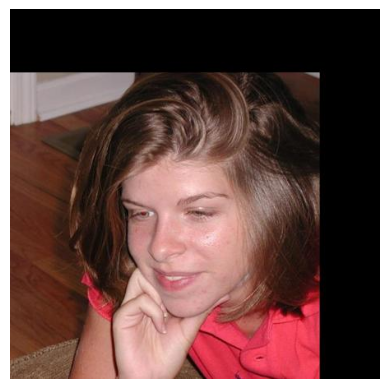

In [13]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

img = mpimg.imread("scripts/notebooks/data/AFW_134212_1_0.jpg")
plt.imshow(img)

plt.axis("off")
plt.show()

In [19]:
img[400, :30, 0]

array([111, 112, 114, 115, 115, 114, 112, 111, 112, 113, 114, 115, 114,
       113, 111, 110, 112, 111, 109, 107, 105, 104, 102, 102, 101,  98,
        95,  95,  97, 100], dtype=uint8)

In [20]:
casting_tensor_output[400, :30, 0]

array([111., 112., 113., 114., 114., 113., 112., 111., 112., 113., 114.,
       114., 114., 113., 111., 110., 110., 109., 107., 105., 103., 101.,
       102., 101.,  99.,  96.,  94.,  94.,  97., 100.], dtype=float32)

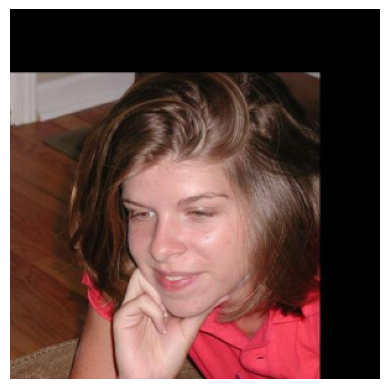

In [25]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

plt.imshow(resize_tensor_output[0].astype(np.uint8))
plt.axis("off")
plt.show()

The image is decoded successfully in the model

In [45]:
model_representation.shape

(1, 2048)

In [14]:
softmax_logits.shape

(1, 1008)

## Test with regular tensorflow image decoding operation to ensure correctness

Create another standalone tensorflow image decoding operation and make sure it works correctly

In [17]:
jpeg_data = tf.placeholder(tf.string, name="decode_jpeg_image")
decoded_image = tf.image.decode_jpeg(jpeg_data, channels=3)

standalone_decoded_image = session.run(decoded_image, feed_dict={jpeg_data: image_data})
standalone_decoded_image.shape

(450, 450, 3)

In [16]:
import numpy as np

assert np.all(standalone_decoded_image == model_decoded_image)

## Visualize the model with tensorboard
We can also write the graph to tensorboard and visualize it.
To start the tensorboard server `tensorboard --logdir models/inception_v3/tensorboard_graph_viz`

In [9]:
train_writer = tf.summary.FileWriter("models/inception_v3/tensorboard_graph_viz/")
train_writer.add_graph(tf.get_default_graph())